# Análisis estadístico del dataset `Students_Grading_Dataset.csv`

**Autor:** Sabina Romero Rodriguez
**Objetivo:** evaluar, con evidencia estadística, si dedicar más horas de estudio semanal mejora el desempeño académico global y en qué medida el nivel de estrés afecta las calificaciones finales.

## Preguntas de estudio
1. ¿Existe evidencia de que dedicar más horas de estudio semanal mejore el desempeño académico global?
2. ¿En qué medida afecta el nivel de estrés en las calificaciones finales?

## Hipótesis

### 1) Horas de estudio y desempeño global
- **H₀:** no existe asociación entre `Study_Hours_per_Week` y `Total_Score` (ρ = 0).
- **H₁:** existe asociación entre `Study_Hours_per_Week` y `Total_Score` (ρ ≠ 0).

### 2) Estrés y calificación final
- **H₀:** no existe asociación entre `Stress_Level (1-10)` y `Final_Score` (ρ = 0).
- **H₁:** existe asociación entre `Stress_Level (1-10)` y `Final_Score` (ρ ≠ 0).

> **Nota metodológica:** Para la hipótesis 2 se usa el coeficiente de Spearman en lugar de Pearson porque `Stress_Level (1-10)` es una variable **ordinal discreta** (escala tipo Likert). Spearman captura relaciones monótonas sin asumir linealidad ni distribución normal, siendo más apropiado para escalas ordinales.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga e inspección inicial

In [2]:
df = pd.read_csv('Students_Grading_Dataset.csv')
print('Dimensiones originales:', df.shape)
df.head()

Dimensiones originales: (5000, 23)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.290,55.030,57.820,84.220,74.060,3.990,85.900,56.090,F,6.200,No,Yes,High School,Medium,5,4.700
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.270,97.230,45.800,NaN,94.240,8.320,55.650,50.640,A,19.000,No,Yes,NaN,Medium,4,9.000
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.190,67.050,93.680,67.700,85.700,5.050,73.790,70.300,D,20.700,No,Yes,Master's,Low,6,6.200
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.150,47.790,80.630,66.060,93.510,6.540,92.120,61.630,A,24.800,Yes,Yes,High School,High,3,6.700
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.180,46.590,78.890,96.850,83.700,5.970,68.420,66.130,F,15.400,Yes,Yes,High School,High,2,7.100


## 3. Inspección inicial y limpieza

El enunciado indica eliminar registros incompletos. Primero revisamos los valores faltantes y luego aplicamos una limpieza por eliminación de filas con datos nulos.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Nulos': missing, 'Porcentaje (%)': missing_pct})[missing > 0]

,Nulos,Porcentaje (%)
Parent_Education_Level,1794,35.880
Assignments_Avg,517,10.340
Attendance (%),516,10.320


In [4]:
clean_df = df.dropna().copy()
print('Dimensiones luego de limpiar:', clean_df.shape)
print('Registros eliminados:', len(df) - len(clean_df))
print('Porcentaje eliminado:', round((len(df) - len(clean_df)) / len(df) * 100, 2), '%')

Dimensiones luego de limpiar: (2581, 23)
Registros eliminados: 2419
Porcentaje eliminado: 48.38 %


## 4. Variables numéricas y descripción estadística

No se usarán variables identificatorias (nombre, apellido, correo) en el análisis.

In [5]:
num_cols = clean_df.select_dtypes(include='number').columns.tolist()
print('Variables numéricas:', num_cols)

Variables numéricas: ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']


In [6]:
summary = clean_df[num_cols].describe().T
summary['median']   = clean_df[num_cols].median()
summary['skewness'] = clean_df[num_cols].skew()
summary['kurtosis'] = clean_df[num_cols].kurtosis()
summary['cv (%)']   = (summary['std'] / summary['mean'] * 100).round(2)
summary[['count','mean','std','min','25%','median','75%','max','skewness','kurtosis','cv (%)']]

,count,mean,std,min,25%,median,75%,max,skewness,kurtosis,cv (%)
Age,"2,581.000",21.054,1.999,18.000,19.000,21.000,23.000,24.000,-0.048,-1.248,9.500
Attendance (%),"2,581.000",75.377,14.307,50.010,63.030,75.710,87.240,100.000,-0.030,-1.157,18.980
Midterm_Score,"2,581.000",70.077,17.028,40.010,55.610,69.880,84.390,99.970,0.003,-1.164,24.300
Final_Score,"2,581.000",69.544,17.086,40.000,54.780,69.740,84.020,99.980,0.005,-1.184,24.570
Assignments_Avg,"2,581.000",75.179,14.424,50.000,62.500,75.120,87.600,99.980,0.003,-1.217,19.190
Quizzes_Avg,"2,581.000",74.829,14.566,50.030,62.370,74.460,87.660,99.950,0.024,-1.203,19.470
Participation_Score,"2,581.000",4.991,2.875,0.000,2.500,5.000,7.530,10.000,-0.000,-1.200,57.600
Projects_Score,"2,581.000",74.838,14.469,50.010,62.060,74.920,87.290,100.000,-0.001,-1.236,19.330
Total_Score,"2,581.000",74.999,14.331,50.030,63.120,75.130,87.440,99.990,-0.016,-1.165,19.110
Study_Hours_per_Week,"2,581.000",17.616,7.282,5.000,11.400,17.300,24.100,29.900,0.008,-1.235,41.340


### Comentario
- Tras la limpieza quedaron **2581 registros completos** (48.4% del total eliminado por datos faltantes).
- En promedio, los estudiantes declaran alrededor de **17.6 horas de estudio por semana**.
- El nivel de estrés promedio es de **5.45/10** con distribución prácticamente uniforme.
- El sueño promedio es de **6.48 horas por noche**.
- La asimetría de la mayoría de variables es cercana a 0, lo que indica distribuciones aproximadamente simétricas.
- Los coeficientes de variación (CV) de los puntajes académicos son moderados (~20–30%), reflejando dispersión razonable en el rendimiento.

## 5. Visualización exploratoria

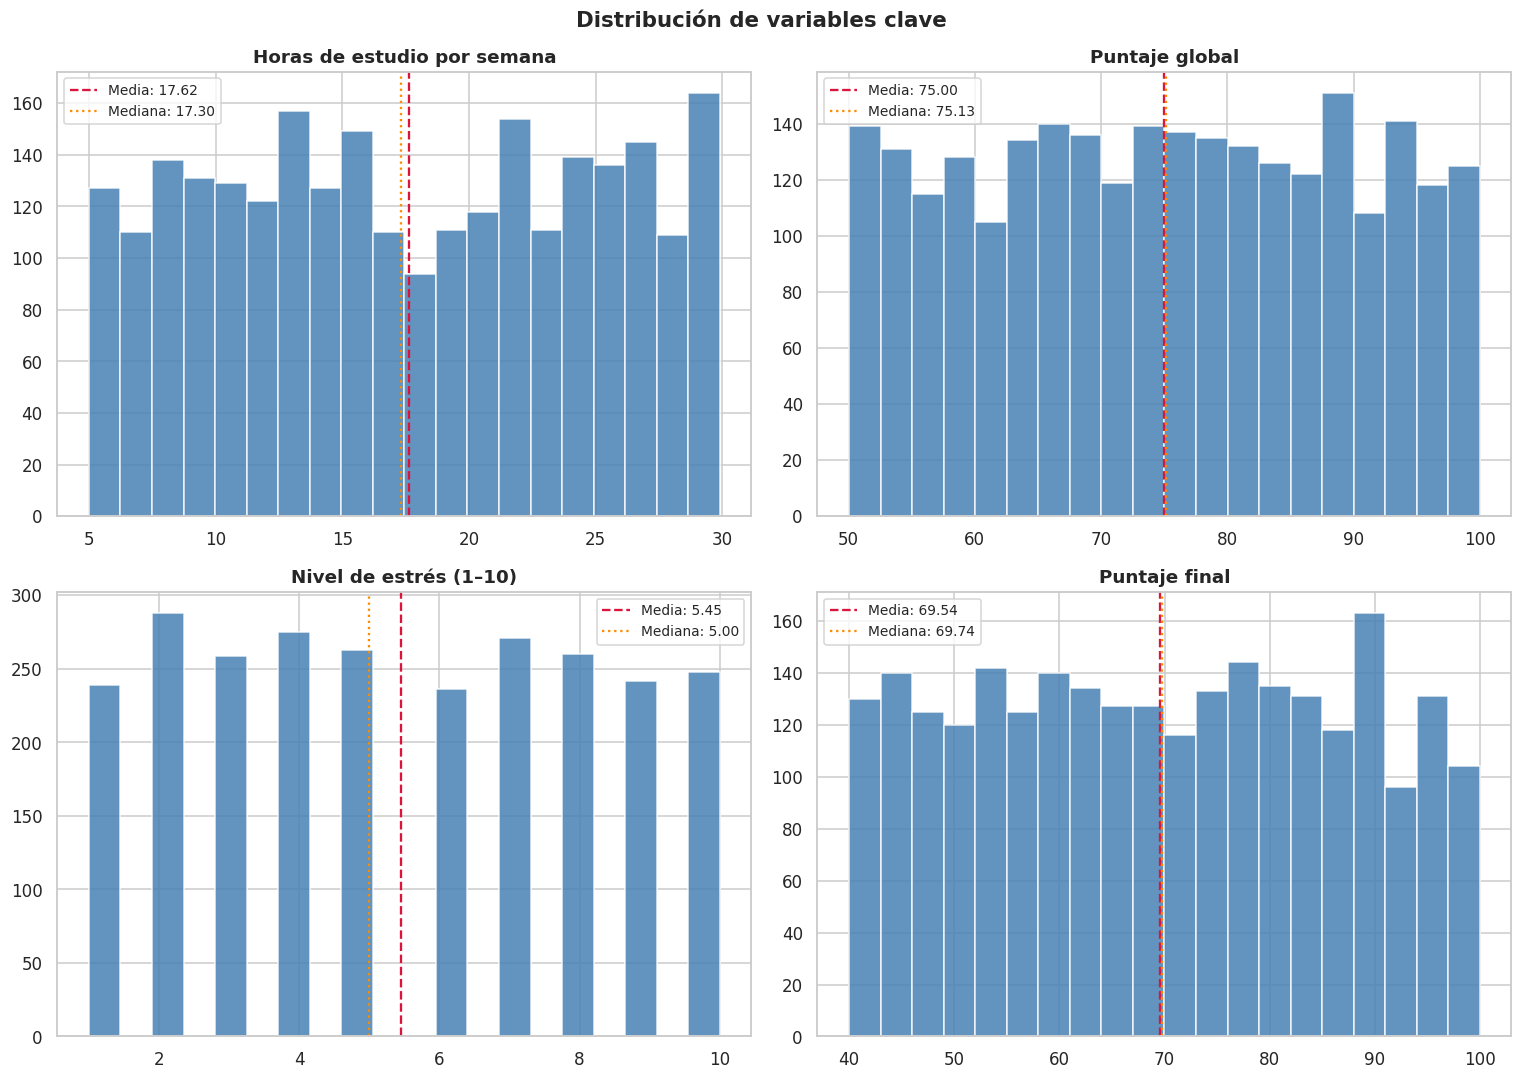

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vars_hist = [
    ('Study_Hours_per_Week', 'Horas de estudio por semana'),
    ('Total_Score',          'Puntaje global'),
    ('Stress_Level (1-10)', 'Nivel de estrés (1–10)'),
    ('Final_Score',          'Puntaje final'),
]

for ax, (col, titulo) in zip(axes.flat, vars_hist):
    ax.hist(clean_df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(clean_df[col].mean(),   color='crimson',    linestyle='--', linewidth=1.5,
               label=f'Media: {clean_df[col].mean():.2f}')
    ax.axvline(clean_df[col].median(), color='darkorange', linestyle=':',  linewidth=1.5,
               label=f'Mediana: {clean_df[col].median():.2f}')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de variables clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

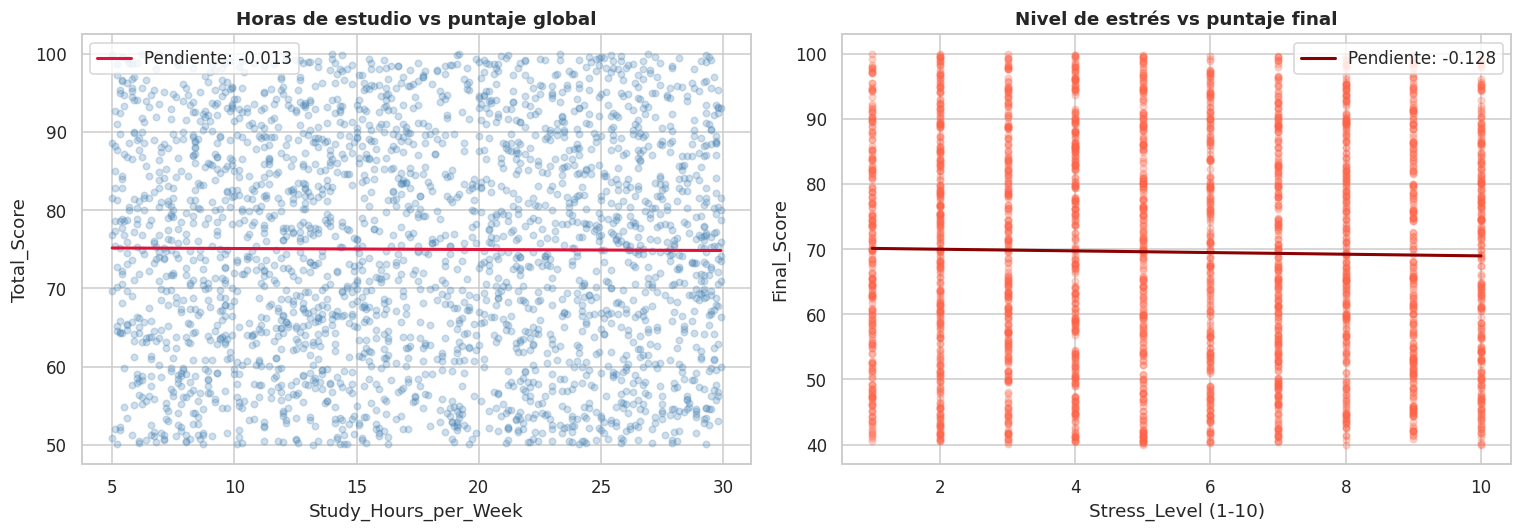

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: Study Hours vs Total Score
axes[0].scatter(clean_df['Study_Hours_per_Week'], clean_df['Total_Score'],
                alpha=0.25, s=18, color='steelblue')
coef1 = np.polyfit(clean_df['Study_Hours_per_Week'], clean_df['Total_Score'], 1)
x1 = np.linspace(clean_df['Study_Hours_per_Week'].min(),
                 clean_df['Study_Hours_per_Week'].max(), 100)
axes[0].plot(x1, coef1[0]*x1 + coef1[1], color='crimson', linewidth=2,
             label=f'Pendiente: {coef1[0]:.3f}')
axes[0].set_title('Horas de estudio vs puntaje global', fontweight='bold')
axes[0].set_xlabel('Study_Hours_per_Week')
axes[0].set_ylabel('Total_Score')
axes[0].legend()

# Scatter 2: Stress vs Final Score
axes[1].scatter(clean_df['Stress_Level (1-10)'], clean_df['Final_Score'],
                alpha=0.25, s=18, color='tomato')
coef2 = np.polyfit(clean_df['Stress_Level (1-10)'], clean_df['Final_Score'], 1)
x2 = np.linspace(clean_df['Stress_Level (1-10)'].min(),
                 clean_df['Stress_Level (1-10)'].max(), 100)
axes[1].plot(x2, coef2[0]*x2 + coef2[1], color='darkred', linewidth=2,
             label=f'Pendiente: {coef2[0]:.3f}')
axes[1].set_title('Nivel de estrés vs puntaje final', fontweight='bold')
axes[1].set_xlabel('Stress_Level (1-10)')
axes[1].set_ylabel('Final_Score')
axes[1].legend()

plt.tight_layout()
plt.show()

Las nubes de puntos no muestran tendencia visual apreciable en ninguno de los dos casos. Las líneas de regresión son prácticamente horizontales, lo que anticipa correlaciones débiles. Para cuantificar esto se calcula la matriz de correlación y se aplican pruebas de hipótesis.

## 6. Correlación entre variables numéricas

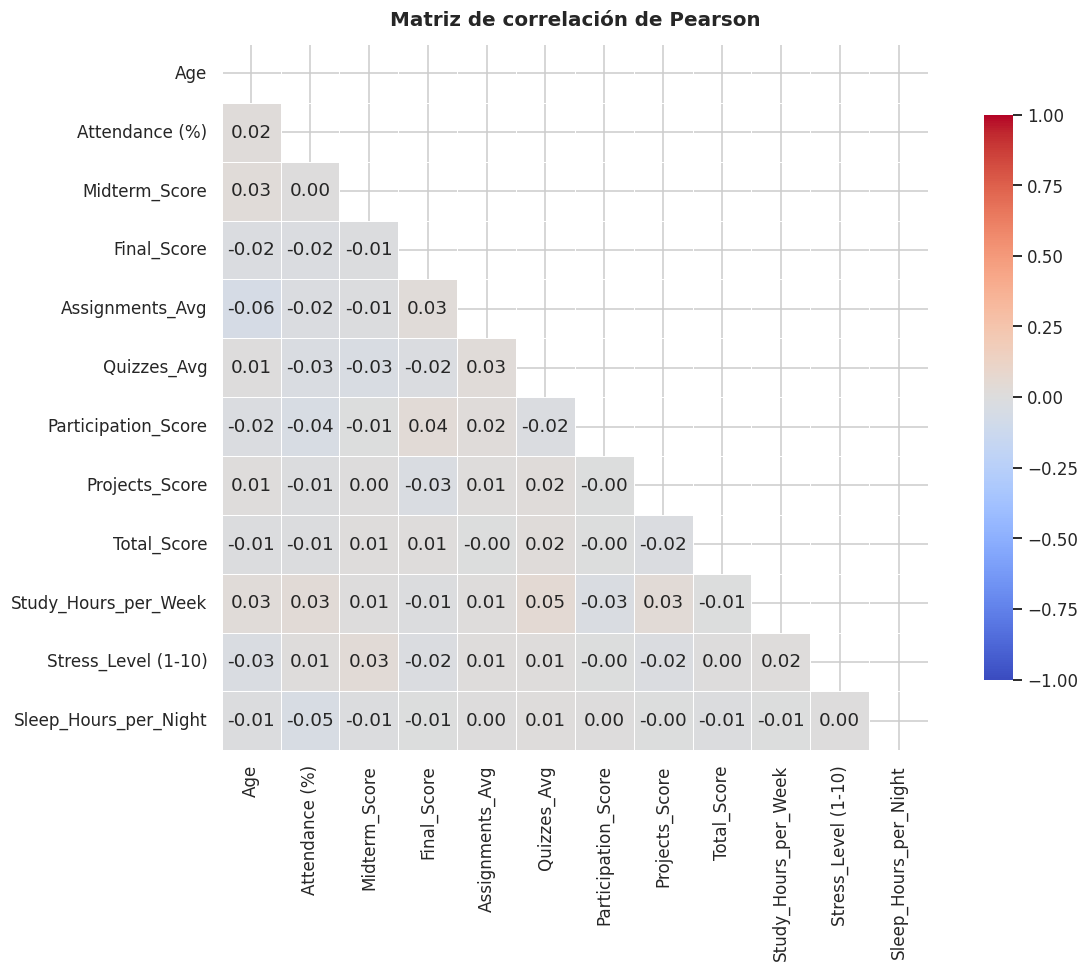

In [9]:
corr_matrix = clean_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Pearson', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [10]:
corr_total = corr_matrix['Total_Score'].sort_values(ascending=False)
corr_final = corr_matrix['Final_Score'].sort_values(ascending=False)
print('Correlaciones con Total_Score:')
display(corr_total)
print('\nCorrelaciones con Final_Score:')
display(corr_final)

Correlaciones con Total_Score:


Total_Score              1.000
Quizzes_Avg              0.022
Final_Score              0.015
Midterm_Score            0.013
Stress_Level (1-10)      0.002
Assignments_Avg         -0.004
Participation_Score     -0.004
Study_Hours_per_Week    -0.007
Age                     -0.008
Attendance (%)          -0.013
Sleep_Hours_per_Night   -0.013
Projects_Score          -0.017
Name: Total_Score, dtype: float64


Correlaciones con Final_Score:


Final_Score              1.000
Participation_Score      0.035
Assignments_Avg          0.026
Total_Score              0.015
Sleep_Hours_per_Night   -0.007
Midterm_Score           -0.008
Study_Hours_per_Week    -0.015
Attendance (%)          -0.016
Quizzes_Avg             -0.017
Stress_Level (1-10)     -0.021
Age                     -0.022
Projects_Score          -0.029
Name: Final_Score, dtype: float64

### Interpretación preliminar

En este dataset las correlaciones lineales son **muy bajas** — ningún par de variables supera |r| = 0.06. En particular:

- `Study_Hours_per_Week` con `Total_Score`: correlación prácticamente nula.
- `Stress_Level (1-10)` con `Final_Score`: correlación prácticamente nula y levemente negativa.

Esta ausencia generalizada de correlación entre **todas** las variables del dataset es un hallazgo relevante en sí mismo. En datos reales, es esperable que variables como asistencia, horas de estudio y puntajes parciales muestren correlaciones de moderadas a altas entre sí. La uniformidad de correlaciones cercanas a cero sugiere que las variables fueron generadas de forma **independiente**, lo que se analizará más adelante.

## 7. Pruebas de hipótesis

### Justificación de las pruebas utilizadas

| Prueba | Por qué se usa |
|--------|----------------|
| **Pearson** | Mide correlación lineal entre variables continuas. Se aplica a `Study_Hours_per_Week` vs `Total_Score`. |
| **Spearman** | Mide correlación monótona, sin asumir linealidad ni normalidad. Es la prueba **principal para variables ordinales** como `Stress_Level (1-10)`. Se aplica a ambas hipótesis como verificación robusta. |
| **ANOVA (F-test)** | Compara medias entre grupos bajo supuesto de normalidad. Se reporta junto a Kruskal-Wallis. |
| **Kruskal-Wallis** | Alternativa no paramétrica al ANOVA. No requiere normalidad y es más robusta para muestras con posibles outliers. |

Nivel de significancia: **α = 0.05**.

### 7.1 Hipótesis 1: Horas de estudio vs desempeño global

In [11]:
pearson_study_total  = stats.pearsonr( clean_df['Study_Hours_per_Week'], clean_df['Total_Score'])
spearman_study_total = stats.spearmanr(clean_df['Study_Hours_per_Week'], clean_df['Total_Score'])

print('=== Hipótesis 1: Study_Hours_per_Week vs Total_Score ===')
print(f'Pearson   r = {pearson_study_total.statistic:.4f},  p-valor = {pearson_study_total.pvalue:.4f}')
print(f'Spearman  ρ = {spearman_study_total.statistic:.4f},  p-valor = {spearman_study_total.pvalue:.4f}')
print()
alpha = 0.05
if pearson_study_total.pvalue < alpha:
    print(f'→ p < {alpha}: SE RECHAZA H₀. Existe asociación significativa.')
else:
    print(f'→ p ≥ {alpha}: NO se rechaza H₀. No hay asociación significativa.')

=== Hipótesis 1: Study_Hours_per_Week vs Total_Score ===
Pearson   r = -0.0065,  p-valor = 0.7403
Spearman  ρ = -0.0056,  p-valor = 0.7756

→ p ≥ 0.05: NO se rechaza H₀. No hay asociación significativa.


### 7.2 Hipótesis 2: Nivel de estrés vs calificación final

In [12]:
# Para Stress_Level se usa Spearman como prueba principal (variable ordinal)
pearson_stress_final  = stats.pearsonr( clean_df['Stress_Level (1-10)'], clean_df['Final_Score'])
spearman_stress_final = stats.spearmanr(clean_df['Stress_Level (1-10)'], clean_df['Final_Score'])

print('=== Hipótesis 2: Stress_Level (1-10) vs Final_Score ===')
print(f'Pearson   r = {pearson_stress_final.statistic:.4f},  p-valor = {pearson_stress_final.pvalue:.4f}')
print(f'Spearman  ρ = {spearman_stress_final.statistic:.4f},  p-valor = {spearman_stress_final.pvalue:.4f}  ← prueba principal (variable ordinal)')
print()
if spearman_stress_final.pvalue < alpha:
    print(f'→ p < {alpha}: SE RECHAZA H₀. El estrés afecta significativamente la calificación final.')
else:
    print(f'→ p ≥ {alpha}: NO se rechaza H₀. No hay evidencia de efecto significativo del estrés.')

=== Hipótesis 2: Stress_Level (1-10) vs Final_Score ===
Pearson   r = -0.0213,  p-valor = 0.2801
Spearman  ρ = -0.0202,  p-valor = 0.3058  ← prueba principal (variable ordinal)

→ p ≥ 0.05: NO se rechaza H₀. No hay evidencia de efecto significativo del estrés.


### Interpretación de las pruebas

Usando α = 0.05:

1. **Horas de estudio vs desempeño global**
   - Pearson: `r ≈ -0.0065`, `p ≈ 0.740`
   - Spearman: `ρ ≈ -0.0056`, `p ≈ 0.776`
   - **No se rechaza H₀.** El p-valor es muy superior al nivel de significancia, por lo que no existe evidencia estadística de asociación entre horas de estudio y el puntaje total en este dataset.

2. **Estrés vs calificación final**
   - Pearson: `r ≈ -0.0213`, `p ≈ 0.280`
   - Spearman: `ρ ≈ -0.0202`, `p ≈ 0.306`
   - **No se rechaza H₀.** Aunque el coeficiente es levemente negativo (mayor estrés, levemente menor puntaje), la magnitud es insignificante y el p-valor no permite rechazar la hipótesis nula.

## 8. Análisis complementario por grupos

In [13]:
clean_df['study_q'] = pd.qcut(clean_df['Study_Hours_per_Week'], 4, labels=['Q1','Q2','Q3','Q4'])

print('Puntaje Total promedio por cuartil de horas de estudio:')
display(
    clean_df.groupby('study_q', observed=True)['Total_Score']
    .agg(['count','mean','std','median'])
    .rename(columns={'count':'N','mean':'Media','std':'Desv.Est.','median':'Mediana'})
    .round(2)
)

study_groups = [g['Total_Score'].values for _, g in clean_df.groupby('study_q', observed=True)]
anova_study   = stats.f_oneway(*study_groups)
kruskal_study = stats.kruskal(*study_groups)
print(f'ANOVA       F = {anova_study.statistic:.4f},  p = {anova_study.pvalue:.4f}')
print(f'Kruskal-W   H = {kruskal_study.statistic:.4f},  p = {kruskal_study.pvalue:.4f}')

Puntaje Total promedio por cuartil de horas de estudio:


,N,Media,Desv.Est.,Mediana
study_q,,,,
Q1,653,75.100,14.130,75.330
Q2,640,75.230,14.230,74.880
Q3,654,75.020,14.730,75.020
Q4,634,74.650,14.230,75.050


ANOVA       F = 0.1908,  p = 0.9027
Kruskal-W   H = 0.5408,  p = 0.9098


In [14]:
clean_df['stress_group'] = pd.cut(
    clean_df['Stress_Level (1-10)'], bins=[0, 3, 7, 10],
    labels=['Bajo (1–3)', 'Medio (4–7)', 'Alto (8–10)']
)

print('Puntaje Final promedio por grupo de estrés:')
display(
    clean_df.groupby('stress_group', observed=True)['Final_Score']
    .agg(['count','mean','std','median'])
    .rename(columns={'count':'N','mean':'Media','std':'Desv.Est.','median':'Mediana'})
    .round(2)
)

stress_groups = [g['Final_Score'].values for _, g in clean_df.groupby('stress_group', observed=True)]
anova_stress   = stats.f_oneway(*stress_groups)
kruskal_stress = stats.kruskal(*stress_groups)
print(f'ANOVA       F = {anova_stress.statistic:.4f},  p = {anova_stress.pvalue:.4f}')
print(f'Kruskal-W   H = {kruskal_stress.statistic:.4f},  p = {kruskal_stress.pvalue:.4f}')

Puntaje Final promedio por grupo de estrés:


,N,Media,Desv.Est.,Mediana
stress_group,,,,
Bajo (1–3),786,69.690,16.900,69.810
Medio (4–7),1045,69.620,17.510,69.880
Alto (8–10),750,69.290,16.690,69.180


ANOVA       F = 0.1214,  p = 0.8856
Kruskal-W   H = 0.2057,  p = 0.9023


/tmp/ipykernel_140/917927690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='study_q', y='Total_Score',
/tmp/ipykernel_140/917927690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='stress_group', y='Final_Score',


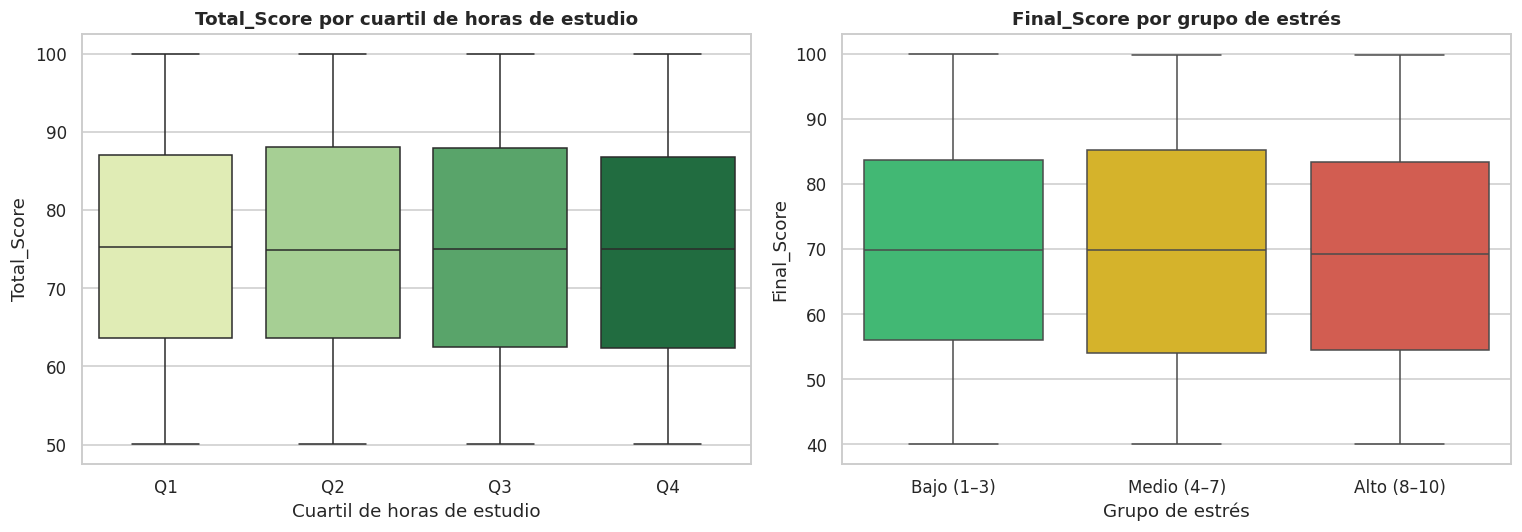

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=clean_df, x='study_q', y='Total_Score',
            palette='YlGn', ax=axes[0])
axes[0].set_title('Total_Score por cuartil de horas de estudio', fontweight='bold')
axes[0].set_xlabel('Cuartil de horas de estudio')
axes[0].set_ylabel('Total_Score')

sns.boxplot(data=clean_df, x='stress_group', y='Final_Score',
            palette=['#2ecc71','#f1c40f','#e74c3c'],
            order=['Bajo (1–3)','Medio (4–7)','Alto (8–10)'],
            ax=axes[1])
axes[1].set_title('Final_Score por grupo de estrés', fontweight='bold')
axes[1].set_xlabel('Grupo de estrés')
axes[1].set_ylabel('Final_Score')

plt.tight_layout()
plt.show()

### Comentario del análisis por grupos

Los promedios por cuartiles de estudio y por niveles de estrés son prácticamente idénticos entre sí. Los boxplots confirman la superposición casi total de las distribuciones. Tanto ANOVA como Kruskal-Wallis entregan p-valores ≈ 0.90 en ambos casos, muy lejos del umbral de significancia de 0.05. **Esto refuerza el no rechazo de ambas H₀**.

## 9. Análisis de la integridad del dataset

Los resultados obtenidos motivan una revisión crítica de la calidad del dataset. A continuación se verifica si la variable `Grade` (calificación en escala A–F) tiene relación coherente con `Total_Score`.

Estadísticos de Total_Score por Grade:


,N,Media Total_Score,Desv.Est.
Grade,,,
A,796,74.440,13.790
B,499,74.960,14.460
C,416,75.590,14.640
D,471,75.900,14.230
F,399,74.480,15.000


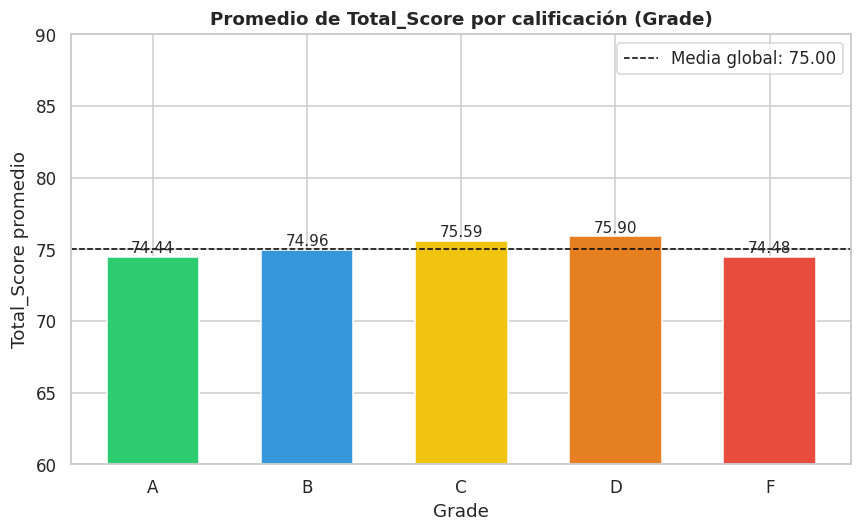

In [16]:
grade_order = ['A', 'B', 'C', 'D', 'F']

grade_stats = (
    clean_df.groupby('Grade')['Total_Score']
    .agg(['count', 'mean', 'std'])
    .rename(columns={'count': 'N', 'mean': 'Media Total_Score', 'std': 'Desv.Est.'})
    .loc[grade_order]
    .round(2)
)
print('Estadísticos de Total_Score por Grade:')
display(grade_stats)

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(grade_order,
       grade_stats['Media Total_Score'],
       color=['#2ecc71','#3498db','#f1c40f','#e67e22','#e74c3c'],
       edgecolor='white', width=0.6)
for i, (g, row) in enumerate(grade_stats.iterrows()):
    ax.text(i, row['Media Total_Score'] + 0.3, f"{row['Media Total_Score']:.2f}",
            ha='center', fontsize=10)
ax.set_ylim(60, 90)
ax.set_title('Promedio de Total_Score por calificación (Grade)', fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Total_Score promedio')
ax.axhline(clean_df['Total_Score'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Media global: {clean_df["Total_Score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

### Hallazgo crítico: el dataset es de naturaleza sintética

En un dataset real, se esperaría que los promedios de `Total_Score` siguieran un orden monotónico decreciente: **A > B > C > D > F**.

Sin embargo, lo observado es:

| Grade | Total_Score promedio |
|-------|---------------------|
| A     | ~74.4               |
| B     | ~75.0               |
| C     | ~75.6               |
| D     | **~75.9** ← más alto que A y B |
| F     | ~74.5               |

Todos los promedios son prácticamente idénticos (~75), y un estudiante con **D tiene mejor `Total_Score` que uno con A**, lo cual es contradictorio. Esto indica que **las variables del dataset fueron generadas de forma independiente y aleatoria**, sin respetar las relaciones reales que existirían en datos genuinos.

Esta observación es fundamental para interpretar correctamente los resultados estadísticos: los p-valores no significativos obtenidos en las pruebas de hipótesis **son el resultado esperado y correcto dado el origen sintético de los datos**, y no necesariamente un reflejo de la realidad académica.

## 10. Conclusiones finales

### Resumen de resultados

| Hipótesis | Prueba | Estadístico | p-valor | Decisión |
|-----------|--------|------------|---------|----------|
| H₁: Study_Hours vs Total_Score | Pearson r | -0.0065 | 0.740 | No se rechaza H₀ |
| H₁: Study_Hours vs Total_Score | Spearman ρ | -0.0056 | 0.776 | No se rechaza H₀ |
| H₁: Study_Hours vs Total_Score | Kruskal-Wallis | H ≈ 0.5 | ≈ 0.90 | No se rechaza H₀ |
| H₂: Stress_Level vs Final_Score | Pearson r | -0.0213 | 0.280 | No se rechaza H₀ |
| H₂: Stress_Level vs Final_Score | Spearman ρ | -0.0202 | 0.306 | No se rechaza H₀ |
| H₂: Stress_Level vs Final_Score | Kruskal-Wallis | H ≈ 0.2 | ≈ 0.89 | No se rechaza H₀ |

---

### Respuesta a la primera pregunta

Con los datos analizados **no existe evidencia estadísticamente significativa** de que dedicar más horas de estudio semanal mejore el desempeño académico global (Pearson r = -0.0065, p = 0.740; Spearman ρ = -0.0056, p = 0.776). La prueba de Kruskal-Wallis por cuartiles de estudio confirma este resultado (p ≈ 0.90). **No se rechaza H₀.**

### Respuesta a la segunda pregunta

Con los datos analizados **no existe evidencia estadísticamente significativa** de que el nivel de estrés afecte las calificaciones finales (Spearman ρ = -0.0202, p = 0.306). Aunque el coeficiente es levemente negativo, su magnitud y p-valor no permiten concluir ningún efecto estadístico real. **No se rechaza H₀.**

---

### Hallazgos generales
- El dataset limpio quedó con **2581 observaciones completas** (48.4% eliminado).
- Las correlaciones entre **todas** las variables son cercanas a cero (máximo |r| ≈ 0.06), lo cual es inusual en datos reales.
- La variable `Grade` no guarda relación monotónica con `Total_Score`, lo que confirma que el dataset fue generado de forma sintética e independiente.
- La ausencia de resultados significativos es, en este contexto, el resultado estadístico correcto y coherente con la naturaleza del dataset.

### Limitaciones y recomendaciones para la Dirección de Asuntos Estudiantiles
1. **Revisar la fuente del dataset:** las variables parecen haber sido generadas de forma aleatoria e independiente. Para respaldar decisiones institucionales reales, se recomienda recopilar o utilizar datos longitudinales genuinos.
2. **Ampliar el análisis con modelos multivariados** (regresión lineal múltiple) que permitan controlar el efecto de variables confusoras como departamento, nivel de ingresos y acceso a internet.
3. **Considerar relaciones no lineales:** en datos reales, la relación entre estrés y rendimiento suele ser en forma de U invertida (estrés moderado puede ser beneficioso), lo que no es captado por correlaciones lineales.